In [1]:
using Revise
includet("diatomic.jl")

using .diatomic_jl.MoleculeTypes
using .diatomic_jl


In [2]:
MoleculeOperator = Molecule.generateMolecule(Rb87Cs133, 2)
beams = Dict("B" =>Hamiltonian.OpticalBeam([1.0, 0.0, 0.0], [0, 1.0, 0.0]))
Hmol_I = Hamiltonian.generateHamiltonian(MoleculeOperator,  Beams = beams);# dirE = [1.0, 0, 0])

In [3]:
IntensityScan = solve.scanIntensity(Hmol_I, 0.1e-4, 420e2, [0:0.1:15...]*1e7);

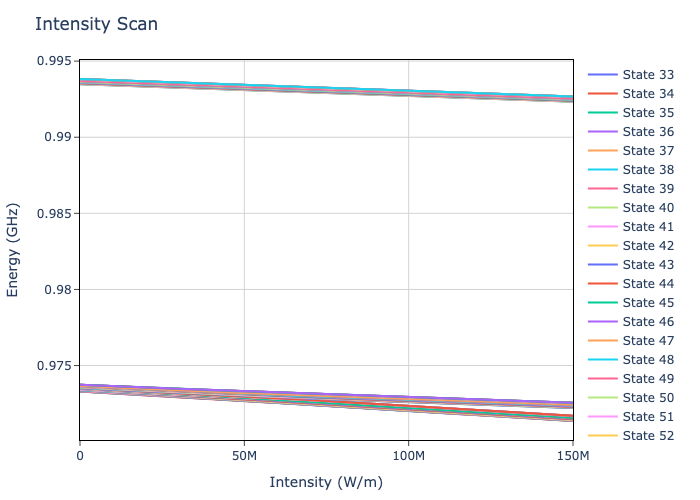

In [4]:
plotting.plotIntensityScan(Hmol_I, IntensityScan, N = [1])

In [2]:

MoleculeOperator = Molecule.generateMolecule(K40Rb87T, 2)
Hmol = Hamiltonian.generateHamiltonian(MoleculeOperator, dirE = [0.0, 1.0, 0.0]);
zeemanScan = solve.scanZeeman(Hmol, [30:1:100...]*1e-4, 47e2);#, nev = 10);

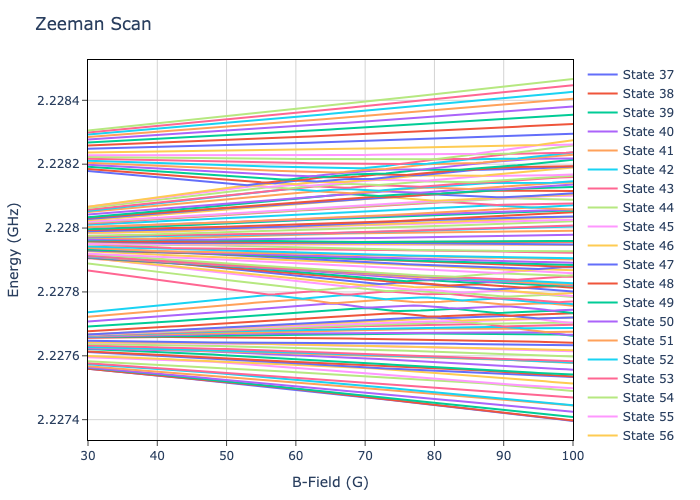

In [179]:
plotting.plotZeemanMap(Hmol, zeemanScan, N = 1)

In [217]:

using LinearAlgebra
indexOI= findfirst(x->x == 50, [i.B_field for i in zeemanScan]*1e4)
eigvals = zeemanScan[indexOI].val;
eigvecs= zeemanScan[indexOI].vec;

stateOI = eigvecs[:, 8];

In [279]:
import .diatomic_jl.calculate: transition_dipole_moment
import .diatomic_jl.Hamiltonian: getDipoleMatrix

In [224]:
statesScan = [1:32...]
comp = [1 ,0, 1]
resR = Matrix{Float64}[]
for stateIndex in statesScan
    stateOI = eigvecs[:, stateIndex];
    res = hcat([transition_dipole_moment(Hmol, stateOI, eigvecs, i) for i = -1:1]...)#transition_dipole_moment(Hmol, stateOI, eigvecs, comp = comp)
    dthres = 0.1
    statesCoupledIndex = vcat([findall(x-> abs(x)> dthres, res[:, i] ) for i in 1:3]...)
    #println(length(statesCoupledIndex))
    resC = zeros(Float64, 2, length(statesCoupledIndex))
    
    resC[1, :] = eigvals[statesCoupledIndex]*1e-6 .-  eigvals[stateIndex]*1e-6
    resC[2, :]  = [maximum(abs.(i)) for i in eachrow(res[statesCoupledIndex, : ])]
    push!(resR, resC) 
end


In [669]:
truncate = 144
DebyeSI = 3.33564e-30


rotationAngle = 30
Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
Ecomp = normalize!(Erot) 
sigmaPcomp = abs(decompose_spherical(Erot)[1])#/sum(abs.(decompose_spherical(Erot)))
PiTime = (12e-6)*2
rabiRate = 1/(2*PiTime);
E_field_hz = rabiRate/(0.23*DebyeSI)*(1/sigmaPcomp)



#Ecomp = normalize!([1.0, 1, 0]) 

E_field_res = E_field_hz*Ecomp

dipOp =  getDipoleMatrix(Hmol.MolOp)
dipOpU = [adjoint(eigvecs)*dip*(eigvecs) for dip in dipOp]


Hmicr = zeros(Float64, size(dipOp[1]))
N_product = Hmol.MolOp.N[1:3] * Hmol.MolOp.N[1:3]
Hmicr[findall(x->isapprox(x, 2), N_product)] .= 1

H0 = Diagonal(eigvals)

mfield = 2228.228e6 ;#- 1.283563615682239*1e3;

H = 2*pi*(H0 - mfield*Hmicr + sum(E_field_res.*dipOpU))
H = H[1:truncate, 1:truncate]

if ! isapprox(H, adjoint(H))
    error("Non-Hermitian Matrix")
end


In [670]:
println((H[135, 135] .- H[24, 24])/(2*pi)*1e-3)

println((H[136, 136] .- H[24, 24])/(2*pi)*1e-3)
println((H[137, 137] .- H[24, 24])/(2*pi)*1e-3)
#println((H[138, 138] .- H[24, 24])/(2*pi)*1e-3)
println(rabiRate*1e-3)

-15.248808032657692 + 2.5895969326204476e-32im
-1.039013243400275 - 2.0680775884187605e-29im
16.554756160056293 + 5.0086594330927195e-31im
20.833333333333332


In [671]:
println(sqrt(abs2.(H[24, 135]))/(2*pi)*1e-3)
println(sqrt(abs2.(H[24, 136]))/(2*pi)*1e-3)
println(sqrt(abs2.(H[24, 137]))/(2*pi)*1e-3)
#sqrt(abs2.(H[24, 137]))/(2*pi)*1e-3
#println(sqrt(abs2.(H[24, 138]))/(2*pi)*1e-3)

4.476681217525401e-8
22.138790335037896
0.36140970786358284


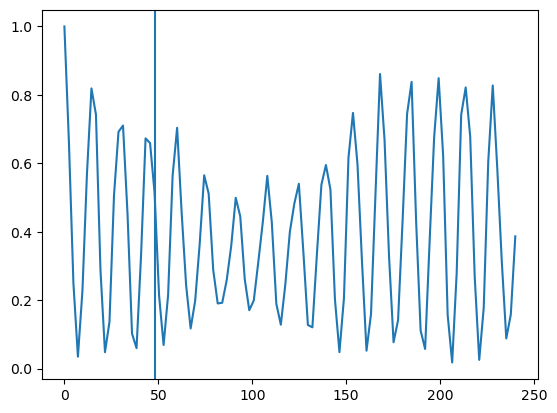

In [630]:
using PyPlot
maxTime = 10*PiTime
tprop = [0:PiTime/10:maxTime...]
popTime = zeros(Float64, length(tprop))
statesOI = [1:144...]
for (i, t_i) in enumerate(tprop)
    Htrunc = H[statesOI, statesOI]
    Uprop = exp(-1im * Htrunc * t_i)
    stateInit = zeros(Float64, size(eigvecs, 1))
    stateInit[24] = 1.0
    stateFinal = adjoint(Uprop)*stateInit[1:truncate][statesOI]
 

    popTime[i] = abs2(stateFinal[argmax(abs2.(stateInit[1:truncate][statesOI]))])
end

clf()
axvline(PiTime*2*1e6)
plot(tprop*1e6, popTime)
figure(gcf())

In [601]:
const pol_v = Dict("sigma_p" => -1 / sqrt(2) * ComplexF64[1, 1im, 0], "sigma_m" => 1 / sqrt(2) * ComplexF64[1, -1im, 0], "pi" => ComplexF64[0, 0, 1])




function decompose_spherical(pol)
   return ComplexF64[ dot(conj(pol_v["sigma_m"]), pol), dot(conj(pol_v["pi"]), pol), dot(conj(pol_v["sigma_p"]), pol)]
end

Ecomp1::Vector{Float64}= [0, 0, 1]
axisX::Vector{Float64} = [1, 0, 0]
axisZ::Vector{Float64} = [0, 0, 1]
function rotation_matrix(axis, theta)
   axis = axis / norm(axis)
   a = cos(theta / 2)
   b, c, d = -axis * sin(theta / 2)
   return [a*a+b*b-c*c-d*d 2*(b*c-a*d) 2*(b*d+a*c)
       2*(b*c+a*d) a*a+c*c-b*b-d*d 2*(c*d-a*b)
       2*(b*d-a*c) 2*(c*d+a*b) a*a+d*d-b*b-c*c]
end

rotationAngle = 80
Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
ErotZ = rotation_matrix(axisZ, 10*pi/180)*Erot

println(Erot)
println(abs2.(decompose_spherical(Ecomp1)))
println(abs2.(decompose_spherical(Erot)))
println(abs2.(decompose_spherical(ErotZ)))

[0.0, 0.9848077530122079, 0.17364817766693041]
[0.0, 1.0, 0.0]
[0.48492315519647683, 0.03015368960704583, 0.48492315519647683]
[0.4849231551964769, 0.03015368960704583, 0.4849231551964769]


In [695]:
using PyPlot


rotationAngle = 80
Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
Ecomp = normalize!(Erot) 
sigmaPcomp = abs(decompose_spherical(Erot)[1])#/sum(abs.(decompose_spherical(Erot)))
PiTime = (12e-6)*2
rabiRate = 1/(2*PiTime);
E_field_hz = rabiRate/(0.23*DebyeSI)*(1/sigmaPcomp)#*(1/2)





E_field_res = E_field_hz*Ecomp
setTime = PiTime
mFieldScan = [2228.08:0.010:2228.4...]*1e6




popN1 = zeros(Float64, 36, length(mFieldScan))
statesOI = [1:144...]

for (i, m_i) in enumerate(mFieldScan)
    H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res.*dipOpU))
    Htrunc = H[statesOI, statesOI]
    Uprop = exp(-1im * Htrunc * setTime)
    for stateGS  = [1:36...]

        stateInit = zeros(Float64, size(eigvecs, 1))
        stateInit[stateGS] = 1.0
        stateFinal = adjoint(Uprop)*stateInit[1:truncate][statesOI]
    

        popN1[stateGS, i] = sum(abs2.(stateFinal[37:144]))
    end
end



In [697]:
function dumpAngle(rotationAngle)
    Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
    Ecomp = normalize!(Erot) 
    sigmaPcomp = abs(decompose_spherical(Erot)[1])#/sum(abs.(decompose_spherical(Erot)))
    PiTime = (12e-6)*2
    rabiRate = 1/(2*PiTime);
    E_field_hz = rabiRate/(0.23*DebyeSI)*(1/sigmaPcomp)#*(1/2)





    E_field_res = E_field_hz*Ecomp
    setTime = PiTime
    mFieldScan = [2228.08:0.010:2228.4...]*1e6




    popN1 = zeros(Float64, 36, length(mFieldScan))
    statesOI = [1:144...]

    for (i, m_i) in enumerate(mFieldScan)
        H = 2*pi*(H0 - m_i*Hmicr + sum(E_field_res.*dipOpU))
        Htrunc = H[statesOI, statesOI]
        Uprop = exp(-1im * Htrunc * setTime)
        for stateGS  = [1:36...]

            stateInit = zeros(Float64, size(eigvecs, 1))
            stateInit[stateGS] = 1.0
            stateFinal = adjoint(Uprop)*stateInit[1:truncate][statesOI]
        

            popN1[stateGS, i] = sum(abs2.(stateFinal[37:144]))
        end
    end

    return popN1
end

    

dumpAngle (generic function with 1 method)

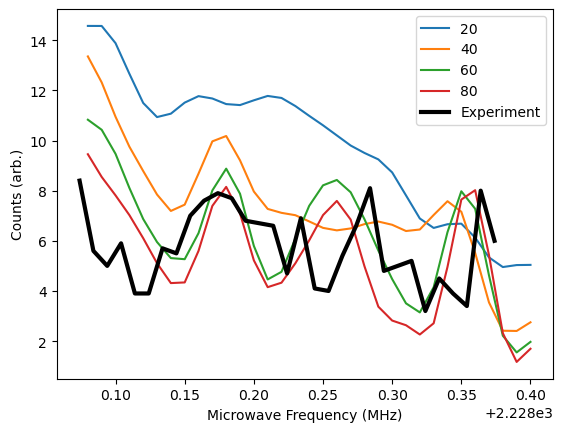

In [719]:

clf()
[plot(mFieldScan*1e-6, sum(dumpAngle(angle), dims = 1)'/1.5, label ="$(angle)") for angle in [20:20:80...]]
plot(x', (y )', label="Experiment", linewidth =3, color="black")
legend()
xlabel("Microwave Frequency (MHz)")
ylabel("Counts (arb.)")
figure(gcf())



In [254]:
res = Hmol.MolOp.N[1:3]*Hmol.MolOp.N[1:3]
isapprox(res[37, 37],  2)

true

In [4]:
import .diatomic_jl: getBasisUC
basisOI = hcat(getBasisUC(Hmol)...)'
sumProj = sum(hcat([basisOI[:, i] for i =  [5,  3]]...), dims = 2)
indsOI = findall(x-> x<  -2.5 && x > -4.5  ,  sumProj)
overlapInit = zeros(size(basisOI, 1), length(indsOI))
for (i, indsI) in enumerate(indsOI)
    overlapInit[indsI[1], i] = 1.0
end
indsOIC = []
overlap = eigvecs'*overlapInit
for colOI in eachcol(overlap) 
    push!(indsOIC, argmax(abs2.(colOI)))
end
indsOIC





UndefVarError: UndefVarError: `eigvecs` not defined

In [3]:
using PyPlot
clf()
colorArray = ["#9B59B6", "#E74C3C", "#E67E22", "#FFC0CB"]
#["purple", "red", "orange", "pink"]
specialArray = ["#9BDB59", "#4CE7E7", "#227EE6", "#CBE6C0"]
#["yellow-green", "cyan", "blue", "light-green"]

stateEmp = [24]
stateEmp = indsOIC
for statePlot = 1:length(resR)
    colorInd= mod(statePlot, length(colorArray)) + 1
    colorSource = statePlot in stateEmp ? specialArray : colorArray
    linewidth = statePlot in stateEmp  ? 5 : 1
    vlines(resR[statePlot][1, :],ymax =  resR[statePlot][2, :],ymin = 0, color=colorSource[colorInd], linewidth = linewidth)
#end
xlim([2228.1,2228.4 ])
xlim([2228.05,2228.4 ])
yplot = y - yb
xplot = x  .- 0.01
plot(xplot', ((yplot .- minimum(yplot))*0.1)')
figure(gcf())



UndefVarError: UndefVarError: `indsOIC` not defined

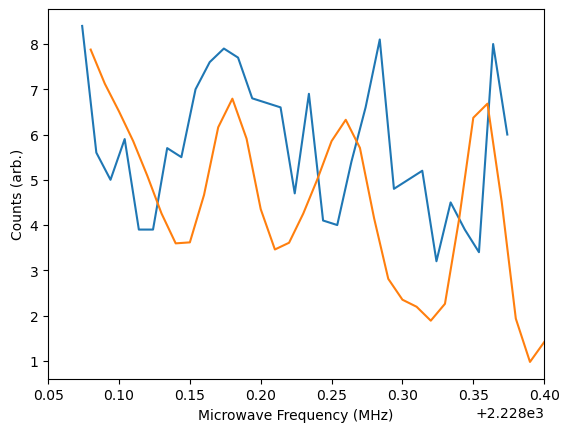

In [674]:
using MAT
data = matopen("res.mat")
x = read(data, "x") 
y = read(data, "y")
yb = read(data, "yb")
clf()
plot(x', (y )')

plot(mFieldScan*1e-6, sum(popN1, dims = 1)'/1.8)
xlim([2228.05,2228.4 ])
ylabel("Counts (arb.)")
xlabel("Microwave Frequency (MHz)")
#figure(gcf())
figure(gcf())


In [29]:
x

1×31 Matrix{Float64}:
 2228.07  2228.08  2228.09  2228.1  …  2228.34  2228.35  2228.36  2228.37

In [39]:
using Tullio
using Base.Threads
include("./QuantumToolbox/QuantumWrapper.jl")
import ..QuantumWrapper.AM_Toolbox: endNode#Basis, Node, angularMomentum, couple, endNodes, AngularNode, getBasis, getBasisUC, is_unitary
#using ..QuantumWrapper.SpinOperator
using LinearAlgebra
#import ..QuantumWrapper.AM_Toolbox: getLayerDepth, getBasisFC, generateLayers, step_up_from, step_up_to
            
function DipoleMatrix(mol)
    F = mol.basisTree
    inds = [node.name == "N" ? 1 : 0 for node in endNode(F)] 
    N = endNode(F)[inds .== 1][1]
    dims = prod([length(node.spin) for node in endNode(F)[inds .== 0]])
    dipoleOperator = [spzeros(ComplexF64, length(N.spin), length(N.spin)) for _ in -1:1] 
    @threads for i in 1:3
        q = i - 2
        compute_SHC_elements!(dipoleOperator[i], q, N, order = 1)
    end

    [kron(sparse(dip), sparse(1.0I, dims, dims)) for dip in dipoleOperator]
end

function transition_dipole_moment(H, gs, eigenstates; M = [-1, 0, 1], comp = [1, 1, 1])
    dipoleMat = DipoleMatrix(H.MolOp)
    tdm = zeros(Float64, length(gs), 3)
    
    @threads for m_i in M
        d = dipoleMat[m_i + 2] 
        @tullio tdm_t[k] := gs[i]*d[i, j]*eigenstates[j, k] #eigenstates*dipoleMat[m_i + 2])*gs#[dot(gs, temp[:, i]) for i in 1:size(temp, 2)] #dot(gs, dipoleMat[m_i + 2]*eigenstates)
        tdm[:, m_i + 2] = real.(tdm_t)*comp[m_i + 2]
    end
    tdm
end
transition_dipole_moment(Hmol, stateOI, eigvecs)

MethodError: MethodError: no method matching endNode(::Main.diatomic_jl.QuantumWrapper.AM_Toolbox.AngularNode)

Closest candidates are:
  endNode(!Matched::Main.QuantumWrapper.AM_Toolbox.AngularNode)
   @ Main.QuantumWrapper ~/Documents/Harvard/NiLab/2025/DSMC/diatomic_jl/QuantumToolbox/AM_Toolbox.jl:51


In [18]:
starkScan = solve.scanStark(Hmol, 0.1e-4, [0:10:1000...]*1e2)#, nev = 10);

101-element Vector{Main.diatomic_jl.solve.sol}:
 Main.diatomic_jl.solve.sol(1.0e-5, 0.0, [1], ComplexF64[3.6179674061758855e-142 + 0.0im 0.0 + 0.0im … -6.972615575939178e-21 + 0.0im 7.72222676060829e-32 + 0.0im; 1.0364332630393693e-46 + 0.0im 0.0 + 0.0im … -9.650951862017356e-17 + 0.0im 1.7847104843901606e-27 + 0.0im; … ; 3.302877604665767e-27 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 3.400648932711654e-17 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im], [-12307.250455213383, -12287.668401116498, -12267.99272397947, -12248.222952765664, -12228.358652756315, -12208.39943985144, -12188.344882661106, -12168.194531616928, -12147.947995425664, -12127.60481596009  …  6.684039766173605e9, 6.68403980103156e9, 6.684039835773083e9, 6.684039870399302e9, 6.684039904911278e9, 6.684039939310078e9, 6.684039973596724e9, 6.684040007772201e9, 6.684040041837473e9, 6.684040075793482e9])
 Main.diatomic_jl.solve.sol(1.0e-5, 1000.0, [1], ComplexF64[2.3038863641278802e-27 - 3.052232790126817e-146im -1.165

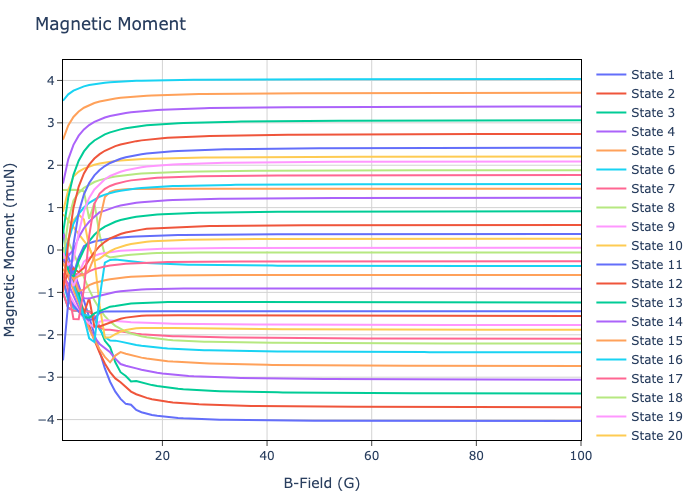

In [24]:
#zeemanScan = solve.scanZeeman(Hmol, [1:1:10...]*1e-4, 420e2)#, nev = 10);
plotting.plotMagneticMoment(Hmol, zeemanScan, "B", N = [0])

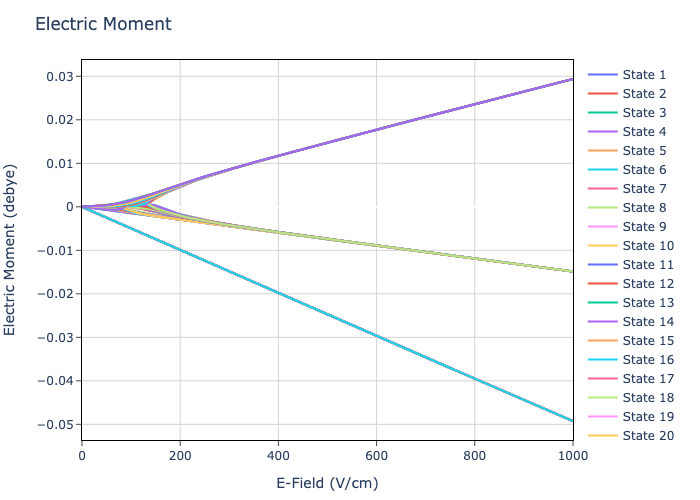

In [20]:
plotting.plotElectricMoment(Hmol, starkScan, "E", N = [0])

In [3]:
Hmol_S = Hamiltonian.generateHamiltonianSparse(MoleculeOperator, dirE = [1.0, 0.0, 0.0]);

In [26]:
AM_Toolbox.getBasisFC(Hmol.MolOp.basisTree, "N")

324-element Vector{Vector{Float64}}:
 [0.0, 0.0, 2.5, -2.5, 1.5, 4.0]
 [-1.0, 1.0, 2.5, -2.5, 1.5, 4.0]
 [0.0, 1.0, 2.5, -2.5, 1.5, 4.0]
 [1.0, 1.0, 2.5, -2.5, 1.5, 4.0]
 [-2.0, 2.0, 2.5, -2.5, 1.5, 4.0]
 [-1.0, 2.0, 2.5, -2.5, 1.5, 4.0]
 [0.0, 2.0, 2.5, -2.5, 1.5, 4.0]
 [1.0, 2.0, 2.5, -2.5, 1.5, 4.0]
 [2.0, 2.0, 2.5, -2.5, 1.5, 4.0]
 [0.0, 0.0, 2.5, -1.5, 1.5, 4.0]
 ⋮
 [0.0, 0.0, 5.5, 5.5, 1.5, 4.0]
 [-1.0, 1.0, 5.5, 5.5, 1.5, 4.0]
 [0.0, 1.0, 5.5, 5.5, 1.5, 4.0]
 [1.0, 1.0, 5.5, 5.5, 1.5, 4.0]
 [-2.0, 2.0, 5.5, 5.5, 1.5, 4.0]
 [-1.0, 2.0, 5.5, 5.5, 1.5, 4.0]
 [0.0, 2.0, 5.5, 5.5, 1.5, 4.0]
 [1.0, 2.0, 5.5, 5.5, 1.5, 4.0]
 [2.0, 2.0, 5.5, 5.5, 1.5, 4.0]

In [3]:

MoleculeOperator = Molecule.generateMolecule(K40Rb87T, 2)
Hmol = Hamiltonian.generateHamiltonian(MoleculeOperator, dirE = [1.0, 0.0, 0.0]);

In [1]:
using PlotlyJS

In [8]:
a = [2, 2,3 , 4]
for (g, i) in enumerate(eachcol(a))
    println(g, i)
end


1

[2, 2, 3, 4]


In [7]:
State(param.vec[:, 36],Hmol)

MethodError: MethodError: no method matching getindex(::Float64, ::Vector{Int64})
Closest candidates are:
  getindex(::Number) at number.jl:95
  getindex(::Union{AbstractChar, Number}, !Matched::CartesianIndex{0}) at multidimensional.jl:867
  getindex(::Number, !Matched::Integer) at number.jl:96
  ...

In [12]:
param = solve.diagonalize(Hmol, 200e-4, 420e2)
stateOI =  State(param.vec[:, 37],Hmol)#State([0.0, 0.0, 0.5, 1.5, -4.0, 4.0], Hmol)
_, eigvec, eigsol, tdm = calculate.findTransition(Hmol,stateOI,  param, comp = [1.0, 1.0, 1.0],[0], NumOfStates = 20)

Starting from 0.852 | -4.0, 1.5, 1.0, 0.0 > + 0.077 | -4.0, 0.5, 1.0, 1.0 > + 0.046 | -4.0, 0.5, 1.0, -1.0 >


State: 0.998 | -1.0, 1.5, 0.0, 0.0 > + 0.001 | 0.0, 0.5, 0.0, 0.0 > + 0.0 | -1.0, 1.5, 1.0, 1.0 >	| Energy (MHz): -2229.1672441512724
	 TDM [sigma_m, pi, sigma_p] = [-1.3665956801378467e-20, -9.894365779359135e-27, 1.9407970107873836e-20]
State: 0.999 | 3.0, 1.5, 0.0, 0.0 > + 0.0 | 3.0, 1.5, 1.0, 1.0 > + 0.0 | 3.0, 1.5, 1.0, -1.0 >	| Energy (MHz): -2228.982023662911
	 TDM [sigma_m, pi, sigma_p] = [-8.360506186286671e-21, 1.1761659966563834e-26, 8.188945333845111e-21]
State: 0.999 | -3.0, 1.5, 0.0, 0.0 > + 0.0 | -3.0, 1.5, 1.0, 1.0 > + 0.0 | -3.0, 1.5, 1.0, -1.0 >	| Energy (MHz): -2229.2597858958507
	 TDM [sigma_m, pi, sigma_p] = [-5.579054888039659e-21, 6.969996517416783e-26, 5.163579999935078e-21]
State: 0.999 | 4.0, 0.5, 0.0, 0.0 > + 0.0 | 4.0, 0.5, 1.0, 1.0 > + 0.0 | 4.0, 0.5, 1.0, -1.0 >	| Energy (MHz): -2228.6490890181694
	 TDM [sigma_m, pi, sigma_p] = [5.2678705351584254e-21, 3.141875550702208e-27, -5.346044891431713e-21]
State: 0.999 | 2.0, 1.5, 0.0, 0.0 > + 0.0 | 2.0, 1.5, 1.0,

([4, 10, 2, 21, 8, 11, 24, 6, 9, 14  …  29, 20, 33, 35, 30, 16, 23, 31, 27, 15], ComplexF64[4.3418715889893475e-13 + 0.0im 9.306280133945725e-17 + 0.0im … 1.931287632960253e-18 + 0.0im 4.3377861033335876e-12 + 0.0im; -1.7089784452849873e-13 + 0.0im 2.949923985304499e-14 + 0.0im … 3.3677222107797486e-9 + 0.0im -3.937367825378215e-13 + 0.0im; … ; 1.3189385912672835e-11 + 0.0im 0.00018028172664106868 + 0.0im … -7.596163547168543e-21 + 0.0im -5.227435846310373e-13 + 0.0im; 0.0 + 0.0im -2.4110837910438632e-20 - 0.0im … -1.13286230192821e-15 - 0.0im 0.0 + 0.0im], [-2.2291672441512723e9, -2.2289820236629114e9, -2.2292597858958507e9, -2.2286490890181694e9, -2.229028344994447e9, -2.2289390896208596e9, -2.228513300972505e9, -2.2290746557560897e9, -2.2289874324290257e9, -2.228842411717799e9, -2.2288907493562584e9, -2.228935692102512e9, -2.229035777696404e9, -2.228412629651531e9, -2.2287457446411896e9, -2.228714825911626e9, -2.228697415359792e9, -2.2293060382979784e9, -2.229213521046911e9, -2.2281

In [4]:
param = solve.diagonalize(Hmol, 200e-4, 420e2)
stateOI =  State([0.0, 0.0, 0.5, 1.5, -3.0, 4.0], Hmol)
stateOI =  State(param.vec[:, 37], Hmol)
_, eigvec, eigsol, tdm = calculate.findTransition(Hmol,stateOI,  param, comp = [1.0, 1.0, 1.0],[1], NumOfStates = 10)

Starting from 0.998 | -3.0, 0.5, 0.0, 0.0 > + 0.001 | -2.0, -0.5, 0.0, 0.0 > + 0.0 | -3.0, 0.5, 1.0, 1.0 >
State: 0.461 | -3.0, 0.5, 1.0, 0.0 > + 0.16 | -3.0, -0.5, 1.0, -1.0 > + 0.129 | -3.0, -0.5, 1.0, 1.0 >	| Energy (MHz): 2229.6298297360872
	 TDM [sigma_m, pi, sigma_p] = [-1.2422685391020052e-17, -9.170091126512993e-6, 1.2089110578372499e-17]
State: 0.758 | -4.0, -0.5, 1.0, 0.0 > + 0.117 | -4.0, -1.5, 1.0, 1.0 > + 0.081 | -4.0, -1.5, 1.0, -1.0 >	| Energy (MHz): 2229.782426933989
	 TDM [sigma_m, pi, sigma_p] = [-8.979512962624409e-17, -5.546985119201949e-6, 4.5319605766684965e-17]
State: 0.788 | -3.0, -1.5, 1.0, 0.0 > + 0.103 | -3.0, -0.5, 1.0, 1.0 > + 0.059 | -3.0, -0.5, 1.0, -1.0 >	| Energy (MHz): 2229.9068324338773
	 TDM [sigma_m, pi, sigma_p] = [-7.109787632525774e-17, -1.7984412088237497e-6, 3.1932776101349326e-17]
State: 0.433 | -3.0, 0.5, 1.0, 0.0 > + 0.237 | -3.0, -0.5, 1.0, -1.0 > + 0.217 | -3.0, -0.5, 1.0, 1.0 >	| Energy (MHz): 2229.5922968101286
	 TDM [sigma_m, pi, sigma_

([65, 75, 84, 62, 67, 79, 72, 66, 78, 91  …  109, 38, 144, 131, 137, 133, 136, 143, 141, 139], ComplexF64[0.0003191191385187996 + 1.2914101961872539e-8im 0.0012744810165939433 - 7.844303868284071e-7im … 9.377485387475437e-6 - 4.025782346060694e-10im 3.5627219885705587e-7 + 2.968980441476795e-12im; -2.376059176912605e-16 - 4.65605922879577e-19im -3.8732164209094084e-15 + 2.819069755038199e-18im … -6.247835602881541e-16 - 3.9837209885469877e-19im 1.2752263166986162e-16 - 9.881412837276454e-19im; … ; -5.5999528721989484e-6 - 2.2661017802368864e-10im -1.179247416193877e-7 + 7.259114777835455e-11im … -0.00018299783101568152 + 7.855859203051659e-9im -1.7612243150495662e-5 - 1.4647833936503093e-10im; -1.3041666618849409e-17 - 0.0im -1.5996579202595492e-18 - 0.0im … 4.433734538447193e-17 - 0.0im -9.694605032515128e-16 - 0.0im], [2.2296298297360873e9, 2.229782426933989e9, 2.2299068324338775e9, 2.2295922968101287e9, 2.229665051760622e9, 2.2298412160996437e9, 2.229727914022402e9, 2.22963339158662

In [ ]:
param = solve.diagonalize(Hmol, 200e-4, 420e2)
stateOI =  State([0.0, 0.0, 0.5, 1.5, -4.0, 4.0], Hmol)
#stateOI =  State(param.vec[:, 37], Hmol)
_, eigvec, eigsol, tdm = calculate.findTransition(Hmol,stateOI,  param, comp = [1.0, 1.0, 1.0],[1], NumOfStates = 10)

In [10]:
zeemanScan = solve.scanZeeman(Hmol, [190:0.1:210...]*1e-4, 420e2)#, nev = 10);
starkScan = solve.scanStark(Hmol, 0.1e-4, [400:1:500...]*1e2)#, nev = 10);


UndefVarError: UndefVarError: Hmol_I not defined

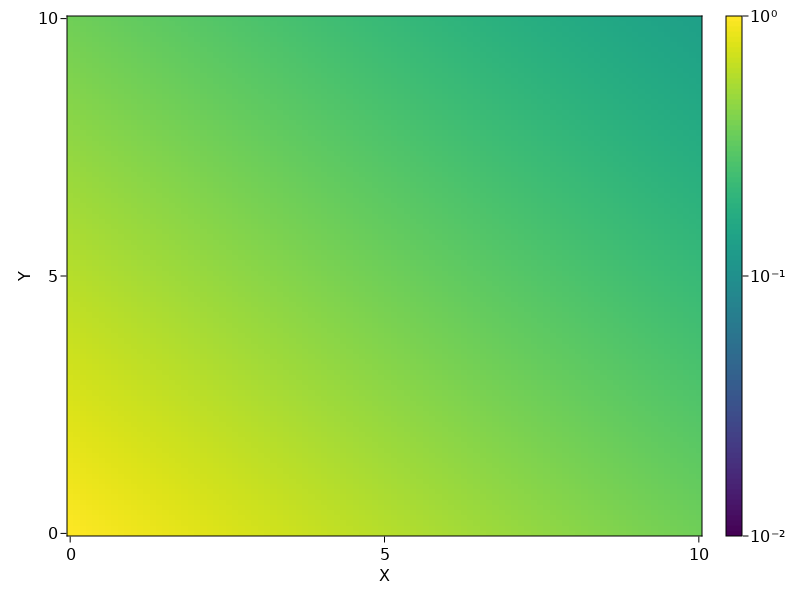

In [47]:
using CairoMakie

# Create some data
x = LinRange(0, 10, 100)
y = LinRange(0, 10, 100)
z = [exp(-0.1*(i+j)) for i in x, j in y]  # Example data roughly in the range [10^(-2), 10^0]

# Manually log-scale the data
z_log = log10.(z)

# Create the figure and axis
fig = Figure()
ax = Axis(fig[1, 1], xlabel="X", ylabel="Y")

# Plot the heatmap with log-scaled color
hm = heatmap!(ax, x, y, z_log, colorrange=(log10(1e-2), log10(1e0)))
custom_formatter(values) = map(
    v -> "10" * Makie.UnicodeFun.to_superscript(round(Int64, v)),
    values
)
# Create colorbar with known log ticks and labels
colorbar_ticks = log10.([1e-2, 1e-1, 1e0])
colorbar_ticklabels = ["10⁻²", "10⁻¹", "10⁰"]
cb = Colorbar(fig[1, 2], hm, tickformat=custom_formatter, ticks=colorbar_ticks)#, ticklabels=colorbar_ticklabels)#, minorticks=LogMinorTicks())
# ... Rest of your plotting code ...

# Manually annotate the colorbar


# Layout settings
#fig.layout[1, 1] = ax
#fig.layout[1, 2] = cb
#fig.layout[1, 1].width = Relative(4/5)
#fig.layout[1, 2].width = Relative(1/5)

# Show figure
fig


In [6]:
colorbar_ticks = log10.([1e-2, 1e-1, 1e0])

3-element Vector{Float64}:
 -2.0
 -1.0
  0.0

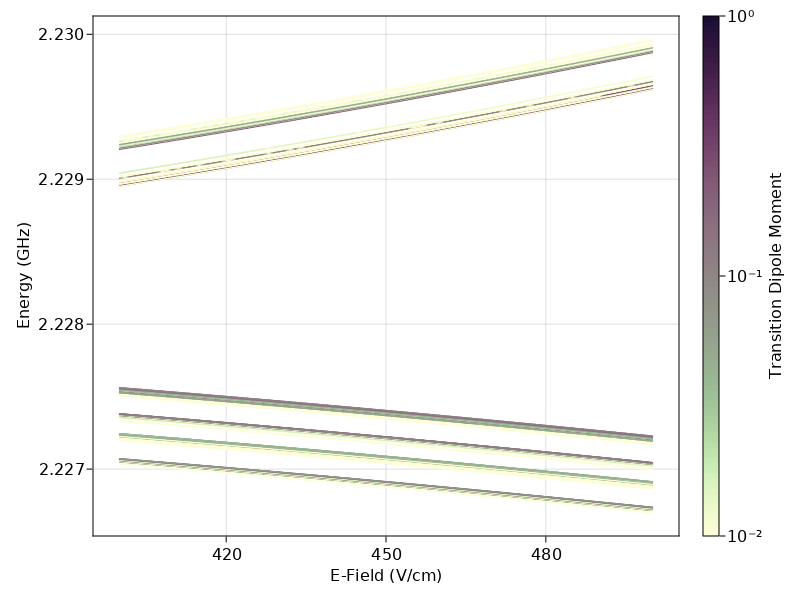

In [52]:
zeemanScan = solve.scanZeeman(Hmol, [0:2:600...]*1e-4, 0)#, nev = 10);

0.5592215055915055


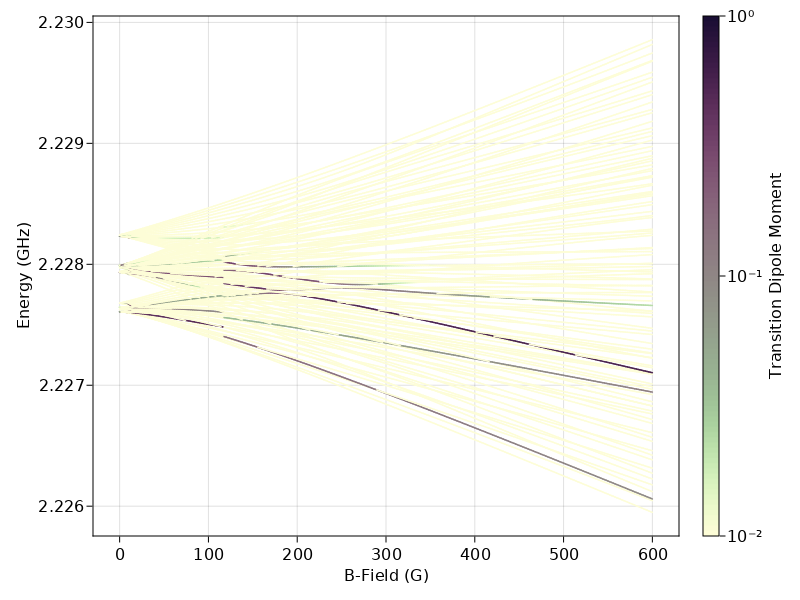

In [62]:
stateOI =  State([0.0, 0.0, 0.5, 1.5, -4.0, 4.0], Hmol)
stateFinal =  State([0.0, 1.0, 0.5, 1.5, -4.0, 4.0], Hmol)
plotting.plotTransitionPlot(Hmol, stateOI, zeemanScan, "B", N = [0], comp = [0, 1, 0])

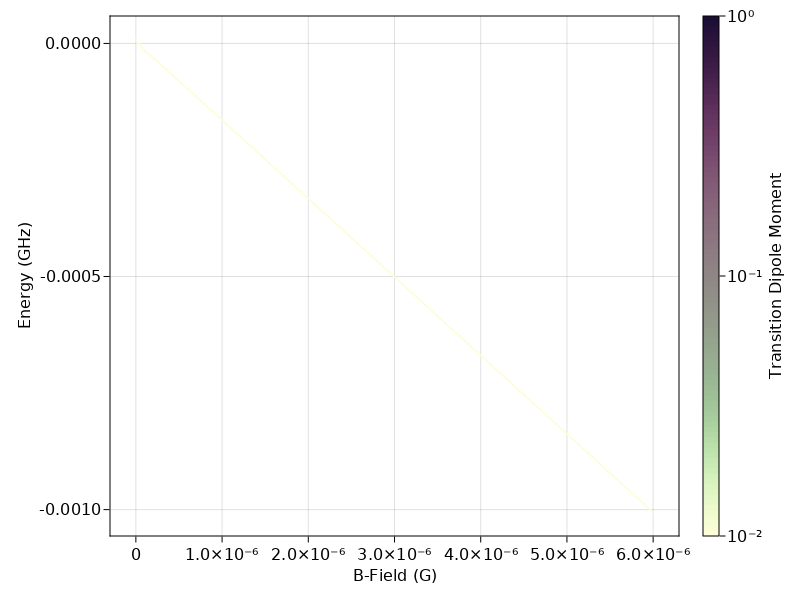

In [61]:
stateFinal =  State([0.0, 1.0, 0.5, 1.5, -4.0, 4.0], Hmol)
plotting.plotTransitionPlot(Hmol, stateOI, stateOI, zeemanScan, "B")

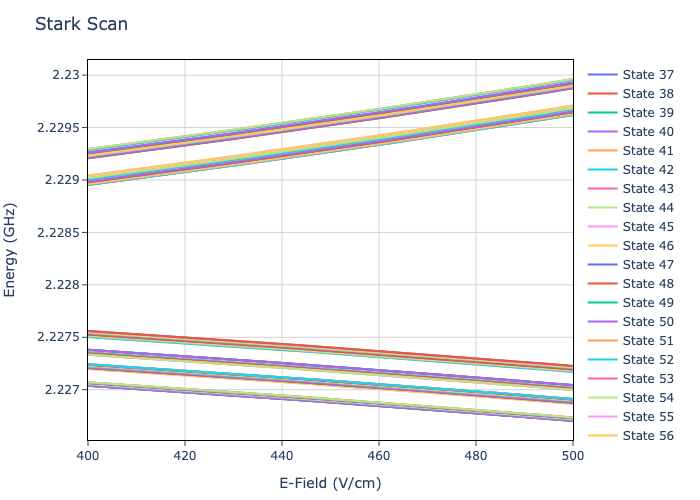

In [32]:
plotting.plotStarkMap(Hmol, starkScan, N =[1])

In [5]:
zeemanScan = solve.scanZeeman(Hmol, [38.910:0.0001:38.916...]*1e-4, 0)#, nev = 10);
avoidedCrossings = calculate.findAvoidedCrossing(stateOI, zeemanScan, [40, 0]*1e-4)

1-element Vector{Any}:
 [0.003891055, 0.16665326160000404]

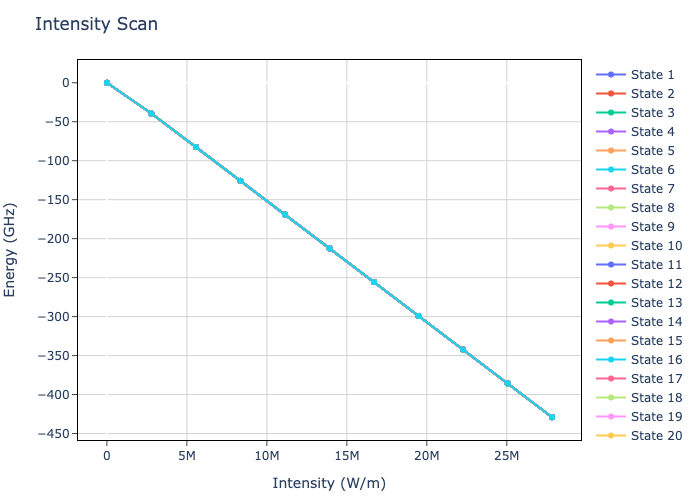

In [8]:
plotting.plotIntensityScan(Hmol_I, IntensityScan, N = [0])

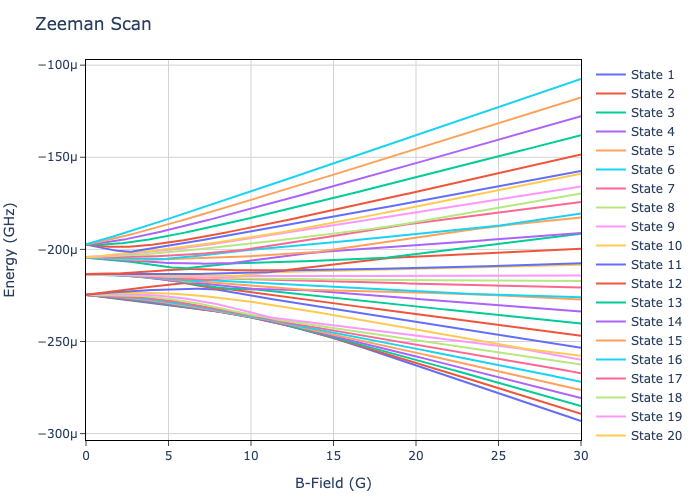

In [13]:
Field_scan = [0:0.1:30...]*1e-4
zeemanScan = solve.scanStark(Hmol, Field_scan, 420e2)#, nev = 10);
stateOI =  State([0.0, 0.0, 0.5, 1.5, -4.0, 4.0], Hmol)
energyScan = calculate.scanDiabiaticEnergy(stateOI, starkScan, [maximum(Field_scan), minimum(Field_scan)], Field = "B")

plotting.plotZeemanMap(Hmol, zeemanScan, N = [0], energyRef = energyScan)

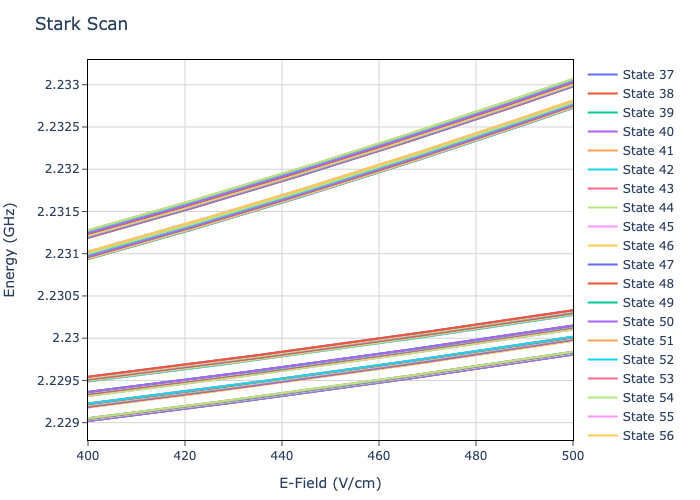

In [9]:
stateOI =  State([0.0, 0.0, 1.5, 1.5, -4.0, 4.0], Hmol)
energyScan = calculate.scanDiabiaticEnergy(stateOI, starkScan, [190, 210]*1e-4, Field = "B")

plotting.plotZeemanMap(Hmol, zeemanScan, N = [1], energyRef = energyScan)

In [526]:
const pol_v = Dict("sigma_p" => -1 / sqrt(2) * ComplexF64[1, 1im, 0], "sigma_m" => 1 / sqrt(2) * ComplexF64[1, -1im, 0], "pi" => ComplexF64[0, 0, 1])




function decompose_spherical(pol)
   return ComplexF64[ dot(conj(pol_v["sigma_m"]), pol), dot(conj(pol_v["pi"]), pol), dot(conj(pol_v["sigma_p"]), pol)]
end

Ecomp1::Vector{Float64}= [0, 0, 1]
axisX::Vector{Float64} = [1, 0, 0]
axisZ::Vector{Float64} = [0, 0, 1]
function rotation_matrix(axis, theta)
   axis = axis / norm(axis)
   a = cos(theta / 2)
   b, c, d = -axis * sin(theta / 2)
   return [a*a+b*b-c*c-d*d 2*(b*c-a*d) 2*(b*d+a*c)
       2*(b*c+a*d) a*a+c*c-b*b-d*d 2*(c*d-a*b)
       2*(b*d-a*c) 2*(c*d+a*b) a*a+d*d-b*b-c*c]
end

rotationAngle = 80
Erot = rotation_matrix(axisX, rotationAngle*pi/180)*Ecomp1
ErotZ = rotation_matrix(axisZ, 10*pi/180)*Erot

println(abs2.(decompose_spherical(Ecomp1)))
println(abs2.(decompose_spherical(Erot)))
println(abs2.(decompose_spherical(ErotZ)))

[0.0, 1.0, 0.0]
[0.48492315519647683, 0.03015368960704583, 0.48492315519647683]
[0.4849231551964769, 0.03015368960704583, 0.4849231551964769]
